In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("Clarity_Text_student_teacher_with_glove.xlsx")  

In [ ]:
#A1
def equal_width_binning(data, bins=4):
    min_val = data.min()
    max_val = data.max()
    width = (max_val - min_val) / bins
    
    binned = np.floor((data - min_val) / width)
    binned[binned == bins] = bins - 1
    return binned.astype(int)

def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    probs = counts / len(target)
    return -np.sum(probs * np.log2(probs))

target = df['glove_0']
target_binned = equal_width_binning(target)

print("Entropy:", entropy(target_binned))

Entropy: 0.32781405788850704


In [16]:
#A2
def gini_index(target):
    values, counts = np.unique(target, return_counts=True)
    probs = counts / len(target)
    return 1 - np.sum(probs**2)

print("Gini Index:", gini_index(target_binned))

Gini Index: 0.09243654016188141


In [25]:
#A3
def information_gain(df, feature, target):
    total_entropy = entropy(df[target])
    
    feature_values = df[feature].astype(str)   
    target_values = df[target].astype(str)     
    
    values, counts = np.unique(feature_values, return_counts=True)
    
    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset = df[feature_values == v]
        weighted_entropy += (c / len(df)) * entropy(subset[target])
    
    return total_entropy - weighted_entropy

def best_feature(df, target):
    features = df.columns.drop(target)
    gains = [information_gain(df, f, target) for f in features]
    return features[np.argmax(gains)]



In [18]:
#A4

def binning(data, bins=4, method='width'):
    if method == 'width':
        return equal_width_binning(data, bins)
    elif method == 'frequency':
        return pd.qcut(data, q=bins, labels=False)
    else:
        return data

In [ ]:
#A5
def build_tree(df, target):
    df = df.copy()
    for col in df.columns:
        df[col] = df[col].astype(str)


    if df.shape[0] == 0:
        return None

   
    if len(np.unique(df[target])) == 1:
        return df[target].iloc[0]


    if len(df.columns) == 1:
        return df[target].mode()[0]

    best = best_feature(df, target)

    if information_gain(df, best, target) == 0:
        return df[target].mode()[0]

    tree = {best: {}}

    for value in np.unique(df[best]):
        subset = df[df[best] == value].drop(columns=[best])

        if subset.shape[0] == 0:
            tree[best][value] = df[target].mode()[0]
        else:
            tree[best][value] = build_tree(subset, target)

    return tree

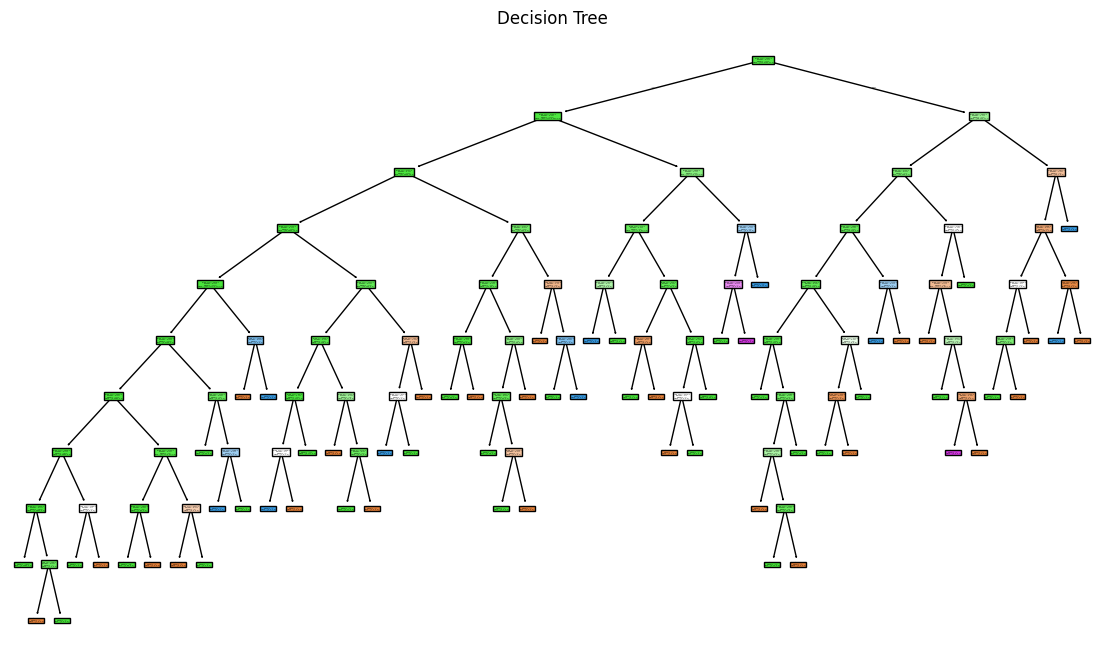

In [ ]:
# A6 

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel("Clarity_Text_student_teacher_with_glove.xlsx") 
target_col = 'glove_0'  

df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])


df[target_col] = pd.cut(df[target_col], bins=4, labels=False)


df_encoded = df.copy()
df_encoded = df_encoded.apply(lambda col: col.astype(str))

for col in df_encoded.columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]


model = DecisionTreeClassifier(criterion='entropy')  
model.fit(X, y)

plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=X.columns, filled=True)
plt.title("Decision Tree")
plt.show()

/Users/majjaripranay/Documents/ML_CODES/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


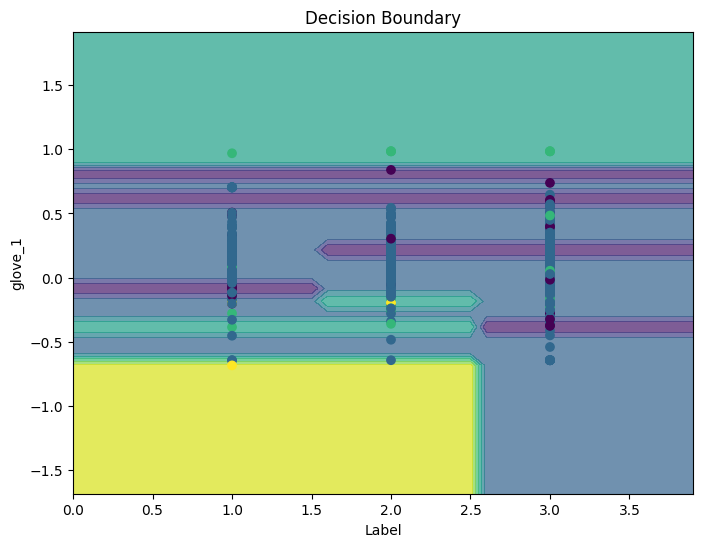

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel("Clarity_Text_student_teacher_with_glove.xlsx")

target_col = 'glove_0'

df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])
df[target_col] = pd.cut(df[target_col], bins=4, labels=False)
numeric_df = df.select_dtypes(include=[np.number])

features = numeric_df.columns.drop(target_col)

feature1, feature2 = features[0], features[1]

X = numeric_df[[feature1, feature2]]
y = numeric_df[target_col]

model = DecisionTreeClassifier()
model.fit(X, y)

x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.7)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Decision Boundary")
plt.show()